#### K-Means
- 대표적인 군집 알고리즘으로 군집의 중심(평균)을 찾는 작업
- 클러스터: 군집
- 클러스터링: 군집화하는 방법

In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
fruits = np.load('data/fruits.npy')
fruits.shape

(300, 100, 100)

In [6]:
# 3차원 데이터를 2차원 데이터로 변경
fruits_2d = fruits.reshape(-1, 100*100)
fruits_2d.shape

(300, 10000)

In [7]:
from sklearn.cluster import KMeans

In [27]:
km = KMeans(
    n_clusters=3
)
km.fit(fruits_2d)
km.labels_

array([2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2,
       2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2,
       2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2,
       0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2,
       2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 0, 2,
       2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], d

In [28]:
def draw_fruits(arr, ratio=1):
    n = len(arr)              # 샘플의 개수
    row = int(np.ceil(n/10))  # 한 줄에 10개씩 배치할 때 필요한 행의 수 (올림 처리)
    col = n if row < 2 else 10 # 샘플이 10개 미만이면 샘플 개수만큼, 많으면 무조건 10열
    
    fig, axs = plt.subplots(
        row,
        col,         
        figsize = (col*ratio, row*ratio),
        squeeze = False       # 1행이나 1열이어도 항상 2차원 배열로 axs를 다루기 위함
    )
    
    for i in range(row):
        for j in range(col):
            if i*10+j < n:    # 전체 샘플 개수를 넘지 않을 때만 그리기
                axs[i,j].imshow(arr[i*10+j], cmap='gray')
            axs[i,j].axis('off') # 이미지가 없는 빈 칸도 테두리를 지워 깔끔하게 처리
            
    plt.show()

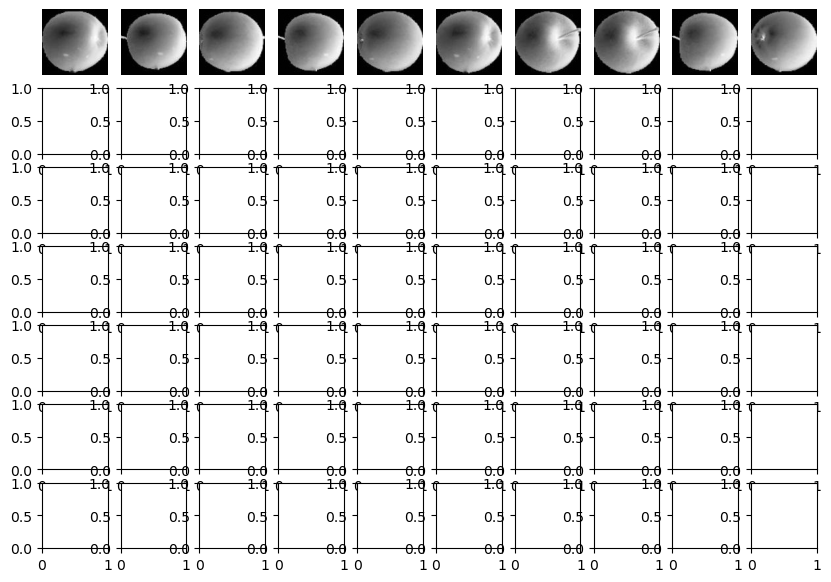

In [29]:
draw_fruits(fruits[km.labels_ == 0])

#### 최적의 K 찾기
- Elbow Method

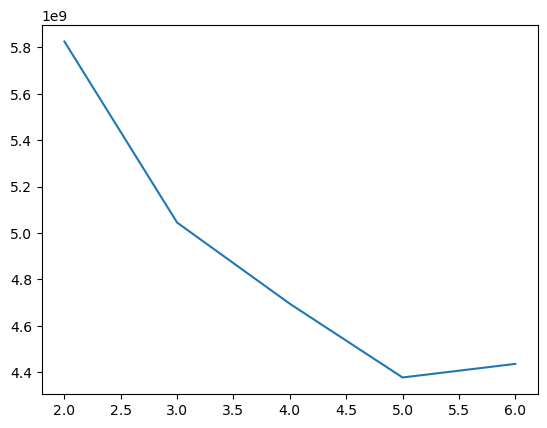

In [30]:
i = []
for k in range(2, 7):
    km = KMeans(
        n_clusters=k
    )
    km.fit(fruits_2d)
    i.append(km.inertia_)
plt.plot(
    range(2, 7),
    i
)
plt.show()